# IE406 - Machine Learning
## Lab-1: Linear Regression using Gradient Descent

**Student ID:** 202301002 <br>
**Name:** Bhumsar Boro

This notebook implements Linear Regression trained with Mini-Batch Gradient Descent, written from scratch using only NumPy (no sklearn models/optimizers are used for the actual training). It follows Tasks 1 to 5 of the lab sheet.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing



## Task 1: Dataset Preparation

**What we do here :**
1. Load the California Housing dataset.
2. Split the data into Train (60%), Validation (20%) and Test (20%) sets, using a fixed seed so the split is always the same.
3. Normalize the input features (make each feature have mean 0 and standard deviation 1). The mean and standard deviation are calculated only from the training set, and the same values are then used to normalize the validation and test sets.
4. Add an extra column of 1s to the features, so that the bias term can be learned as just another weight (matrix multiplication trick).
5. Standardize the target values (house prices) the same way — using only the training set's mean and standard deviation. When we later report performance metrics, we will convert the predictions back to the original (unnormalized) price scale.

In [ ]:

data = fetch_california_housing()
X = np.array(data.data)
y = np.array(data.target)

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (20640, 8)
Target shape: (20640,)


In [ ]:
# randomly split into train (60%) / validation (20%) / test (20%)
np.random.seed(9432)

n_samples = X.shape[0]
indices = np.random.permutation(n_samples)

train_end = int(0.6 * n_samples)
val_end = int(0.8 * n_samples)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train_raw, y_train_raw = X[train_idx], y[train_idx]
X_val_raw, y_val_raw = X[val_idx], y[val_idx]
X_test_raw, y_test_raw = X[test_idx], y[test_idx]

print("Train size:", X_train_raw.shape[0])
print("Validation size:", X_val_raw.shape[0])
print("Test size:", X_test_raw.shape[0])


Train size: 12384
Validation size: 4128
Test size: 4128


In [ ]:
# feature normalization: mean & std computed from the training set
feature_mean = X_train_raw.mean(axis=0)
feature_std = X_train_raw.std(axis=0)

X_train_norm = (X_train_raw - feature_mean) / feature_std
X_val_norm = (X_val_raw - feature_mean) / feature_std
X_test_norm = (X_test_raw - feature_mean) / feature_std

print("Training feature mean (approx 0):", np.round(X_train_norm.mean(axis=0), 3))
print("Training feature std (approx 1):", np.round(X_train_norm.std(axis=0), 3))


Training feature mean (approx 0): [ 0. -0. -0. -0. -0.  0.  0. -0.]
Training feature std (approx 1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# feature augmentation: add a column of 1s for the bias term (placed as the first column)
def augment_with_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

X_train = augment_with_bias(X_train_norm)
X_val = augment_with_bias(X_val_norm)
X_test = augment_with_bias(X_test_norm)

print("Augmented training features shape:", X_train.shape)


Augmented training features shape: (12384, 9)


In [ ]:
# Target standardization: mean & std computed ONLY from the training set
target_mean = y_train_raw.mean()
target_std = y_train_raw.std()

y_train = (y_train_raw - target_mean) / target_std
y_val = (y_val_raw - target_mean) / target_std
y_test = (y_test_raw - target_mean) / target_std

def unstandardize_target(y_scaled):
    """Map standardized predictions/targets back to the original price scale."""
    return y_scaled * target_std + target_mean

print("Standardized training target mean (approx 0):", round(y_train.mean(), 3))
print("Standardized training target std (approx 1):", round(y_train.std(), 3))


Standardized training target mean (approx 0): 0.0
Standardized training target std (approx 1): 1.0


## Task 2: Mini-Batch Gradient Descent (from scratch)

**What we do here :**

We write our own function to train a linear regression model using Mini-Batch Gradient Descent.

- Weights start at all zeros.
- Loss used is Mean Squared Error (MSE), and we compute its gradient by hand using matrix operations.
- Training runs for a maximum of 1000 epochs. In every epoch we shuffle the training data first, then break it into mini-batches and update the weights batch by batch.
- The learning rate stays fixed (no decay).
- After every epoch, we compute the validation MSE (this data is only used to check performance, never to update weights).
- The training MSE reported for an epoch is the sample-weighted average of all the mini-batch losses seen in that epoch (so the last, possibly smaller, batch is weighted correctly).
- **Early stopping:** if the validation MSE does not improve for 100 epochs in a row, we stop training. We always keep a copy of the weights from the epoch with the lowest validation MSE, and that is what the function returns.

In [ ]:
def train_linear_regression(X_train, y_train, X_val, y_val, learning_rate, batch_size,
                             max_epochs=1000, patience=100, seed=9432):
    """
    Trains a linear regression model with Mini-Batch Gradient Descent, implemented from scratch.

    Returns:
        best_weights      : weight vector (including bias) with the lowest validation MSE
        train_mse_history : list of training MSE, one value per completed epoch
        val_mse_history   : list of validation MSE, one value per completed epoch
        best_epoch        : epoch number (0-indexed) at which the lowest validation MSE was found
        best_val_mse      : the lowest validation MSE achieved
    """
    rng = np.random.RandomState(seed)

    n_samples, n_features = X_train.shape
    weights = np.zeros(n_features)
    best_val_mse = np.inf
    best_weights = weights.copy()
    best_epoch = 0
    patience_counter = 0

    train_mse_history = []
    val_mse_history = []

    for epoch in range(max_epochs):

        perm = rng.permutation(n_samples)
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]

        weighted_loss_sum = 0.0
        samples_seen = 0


        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            m = X_batch.shape[0]

            predictions = X_batch @ weights
            errors = predictions - y_batch


            gradient = (2.0 / m) * (X_batch.T @ errors)
            weights = weights - learning_rate * gradient

            batch_mse = np.mean(errors ** 2)
            weighted_loss_sum += batch_mse * m
            samples_seen += m


        epoch_train_mse = weighted_loss_sum / samples_seen


        val_predictions = X_val @ weights
        epoch_val_mse = np.mean((val_predictions - y_val) ** 2)


        if not np.isfinite(epoch_train_mse) or not np.isfinite(epoch_val_mse):
            break

        train_mse_history.append(epoch_train_mse)
        val_mse_history.append(epoch_val_mse)

        # Early stopping bookkeeping
        if epoch_val_mse < best_val_mse:
            best_val_mse = epoch_val_mse
            best_weights = weights.copy()
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_weights, train_mse_history, val_mse_history, best_epoch, best_val_mse


## Task 3: Effect of Learning Rate

**What we do here :**

We train the model with 7 different learning rates (batch size fixed at 128), and for each one we plot the training and validation MSE curves. Then we check which learning rate gives the lowest validation MSE — that is our "best" learning rate for the next task.

In [ ]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
batch_size_task3 = 128

lr_results = {}

for lr in learning_rates:
    weights, train_hist, val_hist, best_epoch, best_val_mse = train_linear_regression(
        X_train, y_train, X_val, y_val,
        learning_rate=lr, batch_size=batch_size_task3
    )
    lr_results[lr] = {
        "weights": weights,
        "train_hist": train_hist,
        "val_hist": val_hist,
        "best_epoch": best_epoch,
        "best_val_mse": best_val_mse,
    }
    print(f"Learning rate = {lr:<8} | epochs run = {len(val_hist):<5} | "
          f"best epoch = {best_epoch:<5} | best val MSE = {best_val_mse:.5f}")


Learning rate = 1e-05    | epochs run = 1000  | best epoch = 999   | best val MSE = 0.47149
Learning rate = 0.0001   | epochs run = 1000  | best epoch = 999   | best val MSE = 0.39684
Learning rate = 0.001    | epochs run = 395   | best epoch = 294   | best val MSE = 0.39166
Learning rate = 0.01     | epochs run = 127   | best epoch = 26    | best val MSE = 0.39059
Learning rate = 0.1      | epochs run = 98    | best epoch = 0     | best val MSE = 646.15472
Learning rate = 1        | epochs run = 3     | best epoch = 0     | best val MSE = 12064232896027967438572177772080732122196338967464345832770733215511168279249638145115815936.00000
Learning rate = 10       | epochs run = 0     | best epoch = 0     | best val MSE = inf


/tmp/ipykernel_1353/630052131.py:57: RuntimeWarning: overflow encountered in square
  epoch_val_mse = np.mean((val_predictions - y_val) ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1353/630052131.py:48: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(errors ** 2)


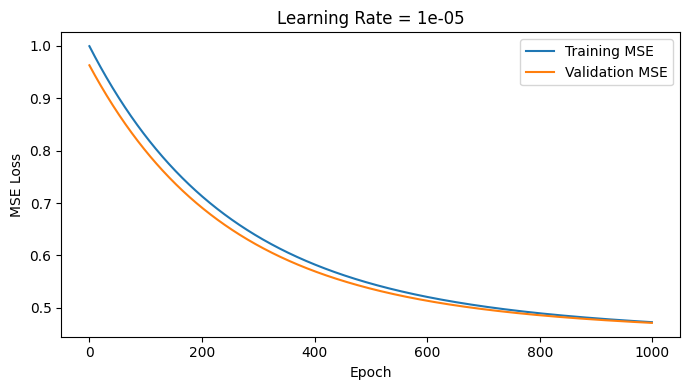

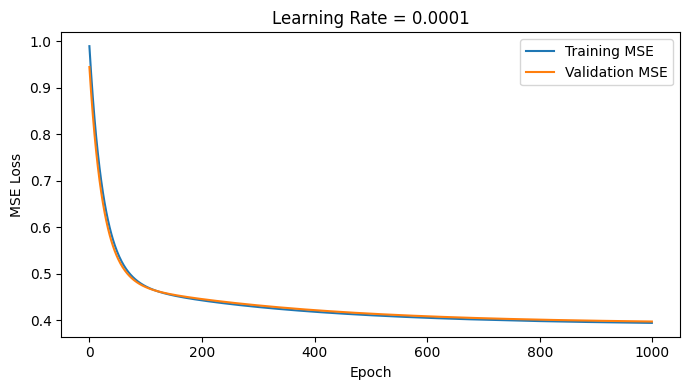

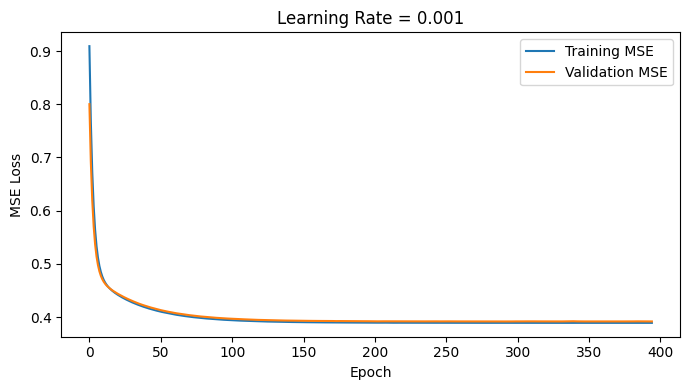

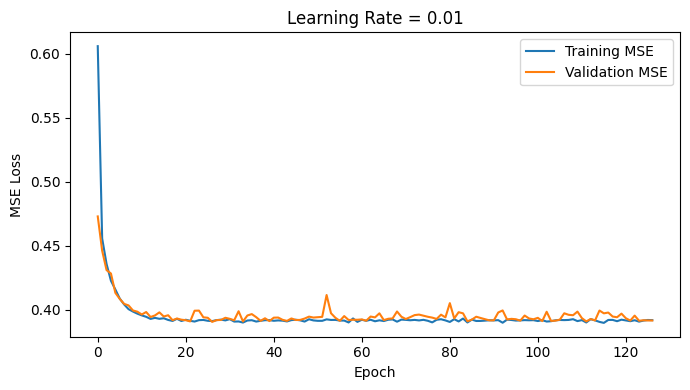

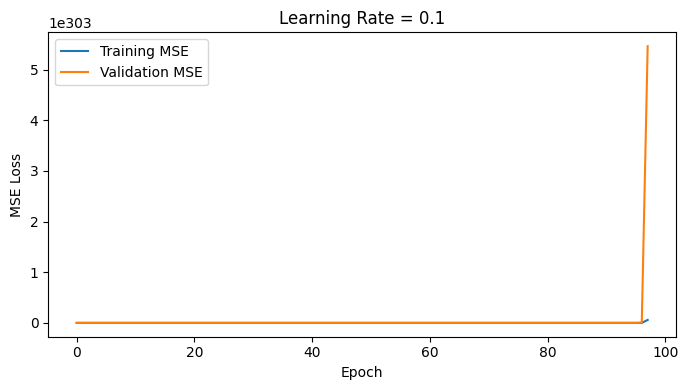

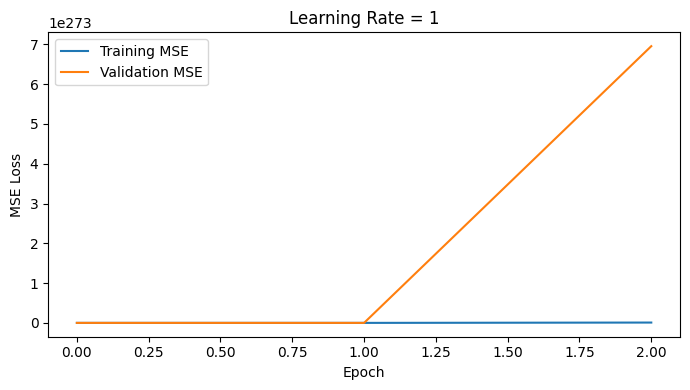

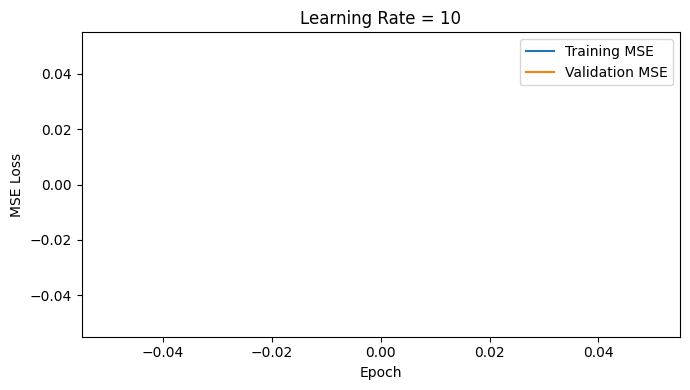

In [14]:
# plots showing training MSE and validation MSE together
for lr in learning_rates:
    result = lr_results[lr]
    plt.figure(figsize=(7, 4))
    plt.plot(result["train_hist"], label="Training MSE", color="tab:blue")
    plt.plot(result["val_hist"], label="Validation MSE", color="tab:orange")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Rate = {lr}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [16]:
# best learning rate (lowest validation MSE)
best_lr = min(lr_results, key=lambda lr: lr_results[lr]["best_val_mse"])
print(f"Best learning rate: {best_lr}")
print(f"Corresponding best validation MSE: {lr_results[best_lr]['best_val_mse']:.5f}")


Best learning rate: 0.01
Corresponding best validation MSE: 0.39059


**Observation:** The best learning rate is printed above (the one with the lowest validation MSE). Very small learning rates (like 1e-5) learn too slowly and don't converge within 1000 epochs, while very large learning rates (like 10) can make training unstable or diverge. This value of `best_lr` is used in Task 4.

## Task 4: Effect of Batch Size

**What we do here:**

Using the best learning rate found in Task 3, we now try 7 different batch sizes: 1, 16, 32, 64, 128, 256 and the entire training set (full-batch gradient descent). For each batch size we record the lowest validation MSE and the epoch at which it happened, and we plot the loss curves to see how smooth or noisy training is.

In [17]:
batch_sizes = [1, 16, 32, 64, 128, 256, X_train.shape[0]]

batch_results = {}

for bs in batch_sizes:
    weights, train_hist, val_hist, best_epoch, best_val_mse = train_linear_regression(
        X_train, y_train, X_val, y_val,
        learning_rate=best_lr, batch_size=bs
    )
    batch_results[bs] = {
        "weights": weights,
        "train_hist": train_hist,
        "val_hist": val_hist,
        "best_epoch": best_epoch,
        "best_val_mse": best_val_mse,
    }
    label = "Full batch" if bs == X_train.shape[0] else str(bs)
    print(f"Batch size = {label:<12} | epochs run = {len(val_hist):<5} | "
          f"best epoch = {best_epoch:<5} | best val MSE = {best_val_mse:.5f}")


/tmp/ipykernel_1353/630052131.py:49: RuntimeWarning: overflow encountered in scalar add
  weighted_loss_sum += batch_mse * m
/tmp/ipykernel_1353/630052131.py:48: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(errors ** 2)


Batch size = 1            | epochs run = 62    | best epoch = 0     | best val MSE = 1831.18349
Batch size = 16           | epochs run = 101   | best epoch = 0     | best val MSE = 152.64076
Batch size = 32           | epochs run = 101   | best epoch = 0     | best val MSE = 1.00687
Batch size = 64           | epochs run = 128   | best epoch = 27    | best val MSE = 0.39026
Batch size = 128          | epochs run = 127   | best epoch = 26    | best val MSE = 0.39059
Batch size = 256          | epochs run = 251   | best epoch = 150   | best val MSE = 0.39120
Batch size = Full batch   | epochs run = 1000  | best epoch = 999   | best val MSE = 0.39640


In [19]:
print(f"{'Batch Size':<15}{'Lowest Val MSE':<20}{'Best Epoch':<12}")
print("-" * 47)
for bs in batch_sizes:
    label = "Full batch" if bs == X_train.shape[0] else str(bs)
    r = batch_results[bs]
    print(f"{label:<15}{r['best_val_mse']:<20.5f}{r['best_epoch']:<12}")


Batch Size     Lowest Val MSE      Best Epoch  
-----------------------------------------------
1              1831.18349          0           
16             152.64076           0           
32             1.00687             0           
64             0.39026             27          
128            0.39059             26          
256            0.39120             150         
Full batch     0.39640             999         


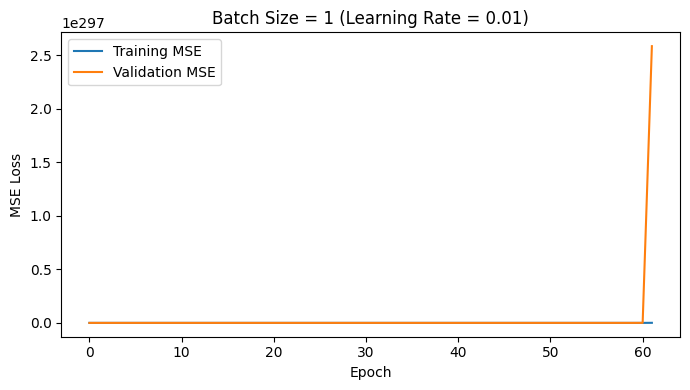

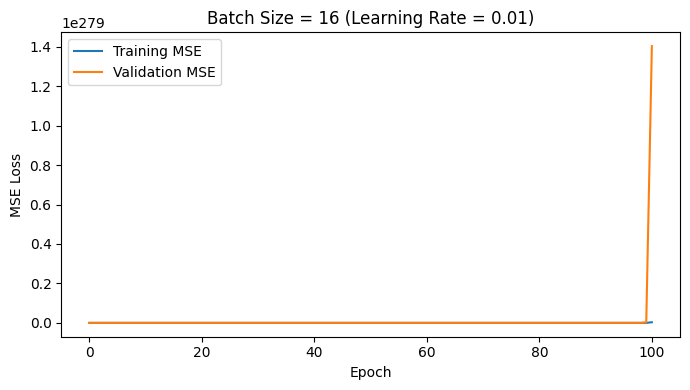

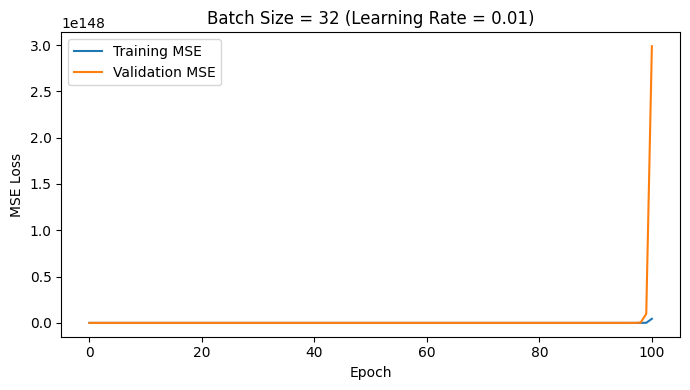

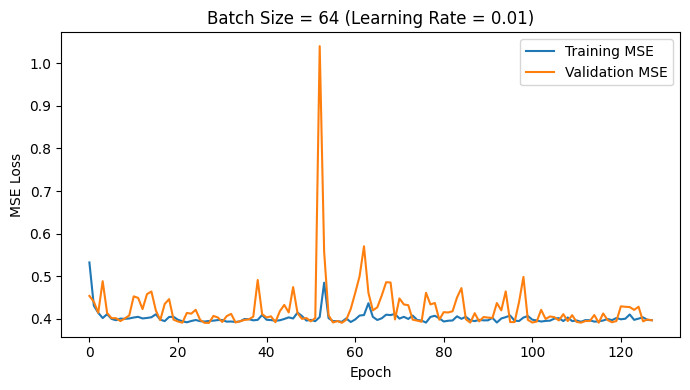

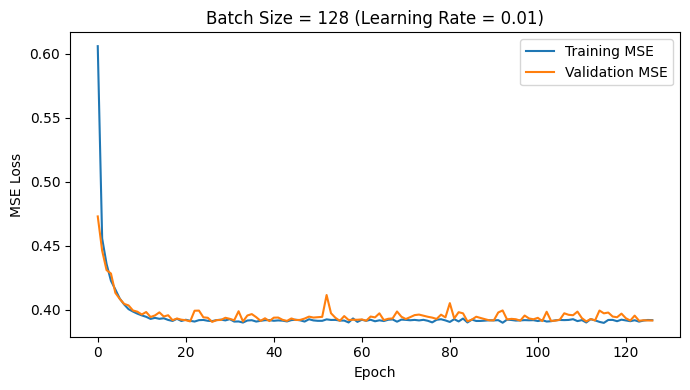

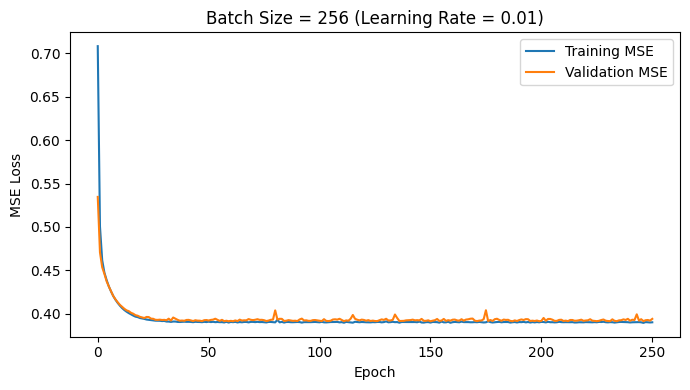

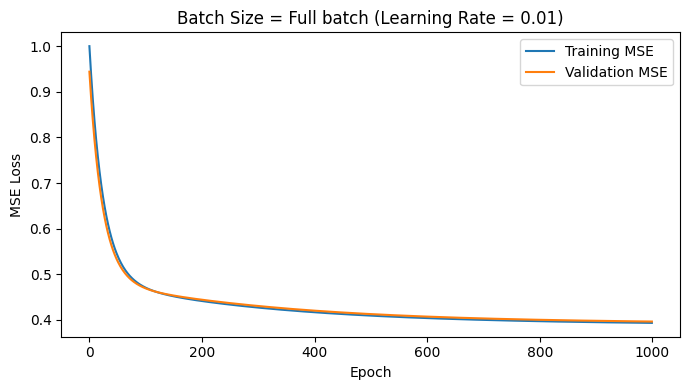

In [20]:
# per batch size showing training MSE and validation MSE together
for bs in batch_sizes:
    result = batch_results[bs]
    label = "Full batch" if bs == X_train.shape[0] else str(bs)
    plt.figure(figsize=(7, 4))
    plt.plot(result["train_hist"], label="Training MSE", color="tab:blue")
    plt.plot(result["val_hist"], label="Validation MSE", color="tab:orange")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Batch Size = {label} (Learning Rate = {best_lr})")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [22]:

best_batch_size = min(batch_results, key=lambda bs: batch_results[bs]["best_val_mse"])
label = "Full batch" if best_batch_size == X_train.shape[0] else str(best_batch_size)
print(f"Best batch size: {label}")
print(f"Corresponding best validation MSE: {batch_results[best_batch_size]['best_val_mse']:.5f}")


Best batch size: 64
Corresponding best validation MSE: 0.39026


**Observation:** Small batch sizes (like 1) usually give noisy, jumpy loss curves because every update is based on very little data. Large batch sizes (like full-batch) give smoother curves but each epoch does fewer weight updates. The batch size selected above (`best_batch_size`) is the one with the lowest validation MSE, and it is carried forward to Task 5.

## Task 5: Inference on Test Set

**What we do here:**

We take the model trained with the best learning rate and best batch size, and evaluate it on the Train, Validation and Test sets. Before computing any metric, predictions are converted back from the standardized scale to the original house-price scale. We report RMSE, MAPE, MAE and R-squared (each rounded to 5 decimal places), and finally plot Actual vs Predicted values for the test set.

In [24]:
# final model = the one trained with best_lr and best_batch_size
final_weights = batch_results[best_batch_size]["weights"]

def predict_original_scale(X, weights):
    """Predict and map back to the original (unnormalized) target scale."""
    y_pred_scaled = X @ weights
    return unstandardize_target(y_pred_scaled)

def compute_metrics(y_true, y_pred):
    """Computes RMSE, MAE, MAPE and R-squared on the ORIGINAL (unnormalized) scale."""
    errors = y_true - y_pred
    rmse = np.sqrt(np.mean(errors ** 2))
    mae = np.mean(np.abs(errors))
    mape = np.mean(np.abs(errors / y_true)) * 100
    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return rmse, mae, mape, r2


In [27]:
# Predictions
y_train_pred = predict_original_scale(X_train, final_weights)
y_val_pred = predict_original_scale(X_val, final_weights)
y_test_pred = predict_original_scale(X_test, final_weights)

# metrics on the original (unnormalized) target values
train_rmse, train_mae, train_mape, train_r2 = compute_metrics(y_train_raw, y_train_pred)
val_rmse, val_mae, val_mape, val_r2 = compute_metrics(y_val_raw, y_val_pred)
test_rmse, test_mae, test_mape, test_r2 = compute_metrics(y_test_raw, y_test_pred)

print(f"{'Set':<12}{'RMSE':<14}{'MAPE (%)':<14}{'MAE':<14}{'R-squared':<14}")
print("-" * 68)
print(f"{'Train':<12}{train_rmse:<14.5f}{train_mape:<14.5f}{train_mae:<14.5f}{train_r2:<14.5f}")
print(f"{'Validation':<12}{val_rmse:<14.5f}{val_mape:<14.5f}{val_mae:<14.5f}{val_r2:<14.5f}")
print(f"{'Test':<12}{test_rmse:<14.5f}{test_mape:<14.5f}{test_mae:<14.5f}{test_r2:<14.5f}")


Set         RMSE          MAPE (%)      MAE           R-squared     
--------------------------------------------------------------------
Train       0.72308       31.52673      0.52756       0.60970       
Validation  0.72304       31.36914      0.53231       0.59536       
Test        0.73017       31.22724      0.53121       0.60382       


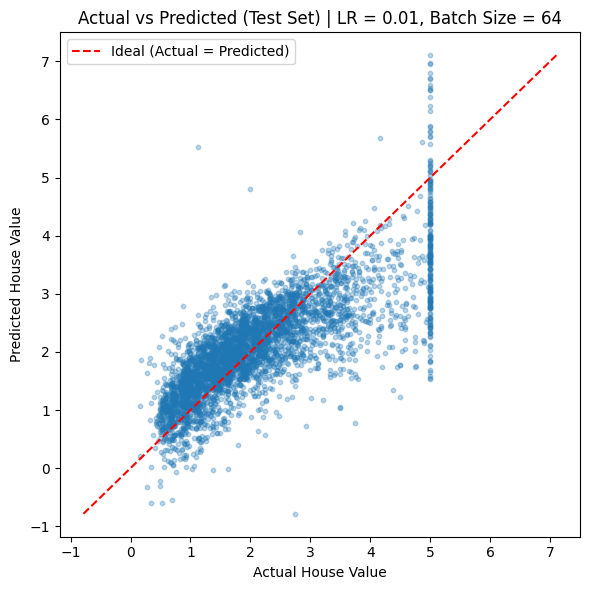

In [28]:

plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw, y_test_pred, alpha=0.3, s=10, color="tab:blue")

min_val = min(y_test_raw.min(), y_test_pred.min())
max_val = max(y_test_raw.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal (Actual = Predicted)")

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title(f"Actual vs Predicted (Test Set) | LR = {best_lr}, Batch Size = "
          f"{'Full batch' if best_batch_size == X_train.shape[0] else best_batch_size}")
plt.legend()
plt.tight_layout()
plt.show()


**Conclusion:** The table above compares Train, Validation and Test performance for the final model (best learning rate and best batch size chosen from Task 3 and Task 4). Close performance across all three sets suggests the model generalizes reasonably well and is not overfitting.